<a href="https://colab.research.google.com/github/EnesCatalbas/Musteri-Segmentasyonu-Uzerine-Veri-Madenciligi/blob/main/ayarlanabilir_graf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analiz edilecek toplam veri sayisi: 20
Temel Graf için kullanılacak düğüm sayisi: 10
Tabloda gösterilecek en yüksek işlem sayısı: 5
K-Means küme sayısı: 3
Hiyerarşik küme sayısı: 5
GMM küme sayısı: 3

En Yüksek Değerlere Göre İlk 5 İşlem 

|   Malatya Merkezilik |   Malatya Merkezilik |          K-Means |   K-Means |       Hiyerarşik |   Hiyerarşik |              GMM |               GMM |
|       Transaction_ID |     Merkezilik_Skoru |   Transaction_ID |      Skor |   Transaction_ID |      HC_Skor |   Transaction_ID |   GMM_Probability |
|---------------------:|---------------------:|-----------------:|----------:|-----------------:|-------------:|-----------------:|------------------:|
|                 1002 |              20.9996 |             1018 |    3.9045 |             1012 |       0.0000 |             1022 |            1.0000 |
|                 1004 |              20.7211 |             1004 |    3.9045 |             1004 |     128.5973 |             1007 |            1.0000 |


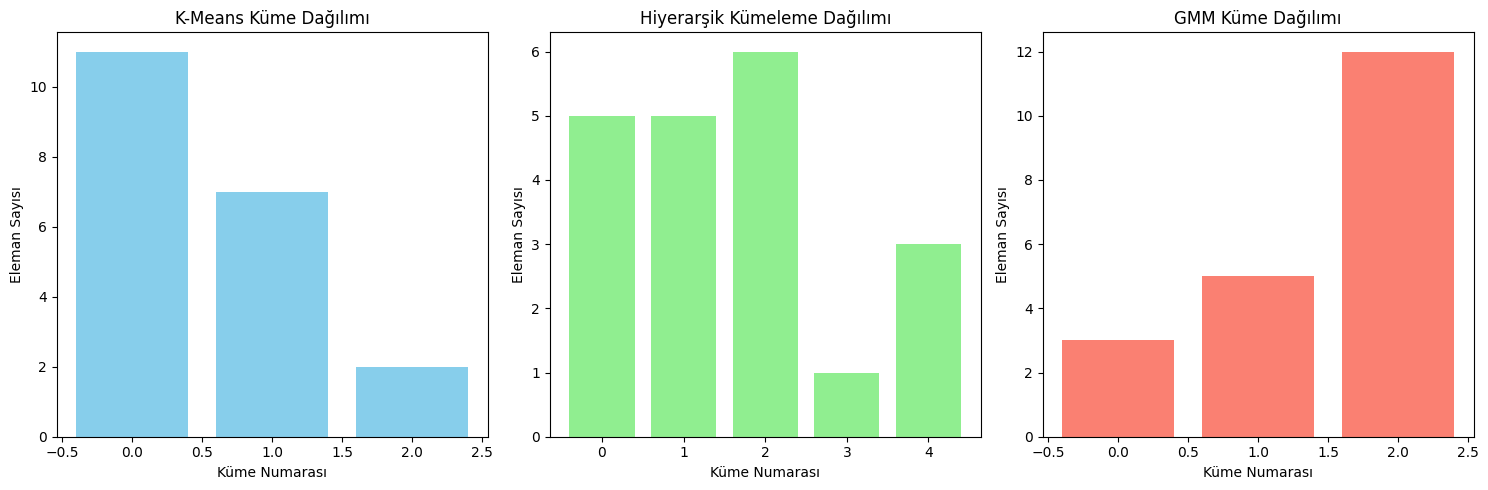

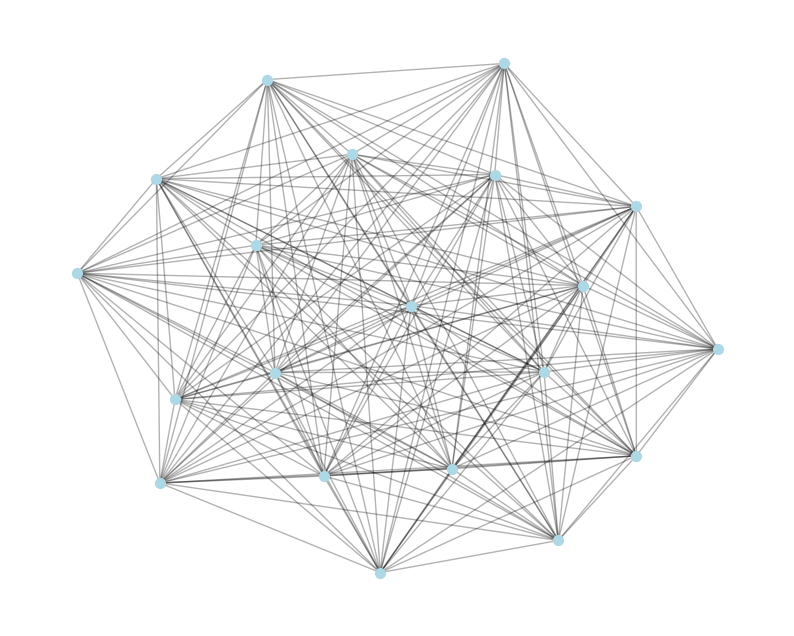

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
import numpy as np
from warnings import simplefilter

simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=UserWarning)

try:
    ANALYSIS_LIMIT_INPUT = input("Analiz edilecek toplam veri sayisi: ")
    BASE_NODES_INPUT = input("Temel Graf için kullanılacak düğüm sayisi: ")
    TOP_N_INPUT = input("Tabloda gösterilecek en yüksek işlem sayısı: ")
    ANALYSIS_LIMIT = int(ANALYSIS_LIMIT_INPUT)
    BASE_NODES = int(BASE_NODES_INPUT)
    TOP_N = int(TOP_N_INPUT)
except ValueError:
    print("Hata: Lütfen geçerli bir tam sayı girin.")
    exit()

if BASE_NODES <= 0:
    print(f"Hata: Temel düğüm sayısı ({BASE_NODES}) pozitif olmalı. Varsayılan 10 kullanılıyor.")
    BASE_NODES = 10
if ANALYSIS_LIMIT < BASE_NODES:
    print(f"Hata: Analiz limiti ({ANALYSIS_LIMIT}), temel düğüm sayısından büyük olmalı. Varsayılan {BASE_NODES + 10} kullanılıyor.")
    ANALYSIS_LIMIT = BASE_NODES + 10

try:
    df = pd.read_csv("customer_spending_1M_2018_2025.csv")
except FileNotFoundError:
    print("Hata: 'customer_spending_1M_2018_2025.csv' dosyası bulunamadı.")
    exit()

df = df.dropna(subset=['Transaction_ID', 'Gender', 'Age', 'Marital_status',
                       'Segment', 'Amount_spent', 'Employees_status',
                       'Payment_method', 'Referral', 'State_names', 'Transaction_date'])

df_analysis = df.head(ANALYSIS_LIMIT).copy()
df_analysis = df_analysis.reset_index(drop=True).reset_index().rename(columns={'index': 'Sıra'})
df_analysis['Sıra'] = df_analysis['Sıra'] + 1

def similarity(a, b):
    sim = 0
    categorical_features = ['Gender', 'Marital_status', 'Segment', 'Employees_status',
                             'Payment_method', 'Referral', 'State_names']
    for feature in categorical_features:
        if a[feature] == b[feature]:
            sim += 1
    try:
        date_a = pd.to_datetime(a['Transaction_date'])
        date_b = pd.to_datetime(b['Transaction_date'])
        if (date_a.year == date_b.year) and (date_a.month == date_b.month):
            sim += 1
    except:
        pass
    if abs(a['Age'] - b['Age']) <= 5:
        sim += 1
    amount_a, amount_b = a['Amount_spent'], b['Amount_spent']
    if amount_a == 0 and amount_b == 0:
        sim += 1
    elif amount_a != 0 or amount_b != 0:
        max_amount = max(amount_a, amount_b)
        difference = abs(amount_a - amount_b)
        if max_amount > 0 and difference <= (max_amount * 0.10):
            sim += 1
    return sim

def merkezilik_hesapla(G):
    merkezilik_skorlari = {}
    dereceler = dict(G.degree(weight='weight'))
    for node in G.nodes():
        node_derecesi = dereceler[node]
        oranlar_toplami = 0
        if node_derecesi == 0:
            merkezilik_skorlari[node] = 0
            continue
        for neighbor in G.neighbors(node):
            komsu_derecesi = dereceler[neighbor]
            if komsu_derecesi > 0:
                oranlar_toplami += node_derecesi / komsu_derecesi
        merkezilik_skorlari[node] = oranlar_toplami
    return merkezilik_skorlari

all_transactions = df_analysis['Transaction_ID'].tolist()
all_similarities = {}

for t1, t2 in combinations(all_transactions, 2):
    a = df_analysis[df_analysis['Transaction_ID'] == t1].iloc[0]
    b = df_analysis[df_analysis['Transaction_ID'] == t2].iloc[0]
    sim = similarity(a, b)
    if sim > 0:
        all_similarities[(t1, t2)] = sim

G_full = nx.Graph()
G_full.add_nodes_from(all_transactions)
for (t1, t2), sim in all_similarities.items():
    G_full.add_edge(t1, t2, weight=sim)

full_centrality_scores = merkezilik_hesapla(G_full)
malatya_results_df = pd.DataFrame(list(full_centrality_scores.items()), columns=['Transaction_ID', 'Merkezilik_Skoru'])
malatya_results_df = pd.merge(malatya_results_df, df_analysis[['Transaction_ID', 'Sıra']], on='Transaction_ID', how='left')
malatya_results_df.set_index('Sıra', inplace=True)

df_analysis['Transaction_date'] = pd.to_datetime(df_analysis['Transaction_date'])
df_analysis['Month'] = df_analysis['Transaction_date'].dt.month
df_analysis['Year'] = df_analysis['Transaction_date'].dt.year

categorical_features = ['Gender', 'Marital_status', 'Segment', 'Employees_status',
                        'Payment_method', 'Referral', 'State_names']
df_cluster = pd.get_dummies(df_analysis, columns=categorical_features, drop_first=True)

feature_cols = ['Age', 'Amount_spent', 'Month', 'Year'] + [col for col in df_cluster.columns if any(cat_feat in col for cat_feat in categorical_features)]
X = df_cluster[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k_clusters = min(10, max(2, int(np.sqrt(len(df_analysis) / 2))))
kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
df_cluster['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
df_cluster['Distance_to_Centroid'] = kmeans.transform(X_scaled).min(axis=1)

print(f"K-Means küme sayısı: {k_clusters}")
kmeans_table = df_cluster['KMeans_Cluster'].value_counts().reset_index()
kmeans_table.columns = ['Küme Numarası', 'Eleman Sayısı']

hc_clusters = min(25, max(5, len(df_analysis)//20))
hc_model = AgglomerativeClustering(n_clusters=hc_clusters, metric='euclidean', linkage='ward')
df_cluster['HC_Cluster'] = hc_model.fit_predict(X_scaled)

print(f"Hiyerarşik küme sayısı: {hc_clusters}")
hc_table = df_cluster['HC_Cluster'].value_counts().reset_index()
hc_table.columns = ['Küme Numarası', 'Eleman Sayısı']

hc_centers = df_cluster.groupby('HC_Cluster')[feature_cols].mean()
distances = []
for i, row in df_cluster.iterrows():
    cluster_id = row['HC_Cluster']
    center = hc_centers.loc[cluster_id].values
    dist = np.linalg.norm(row[feature_cols].values - center)
    distances.append(dist)
df_cluster['HC_Distance_to_Center'] = distances

gmm_clusters = k_clusters
gmm = GaussianMixture(n_components=gmm_clusters, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
log_probs = gmm.score_samples(X_scaled)
scaler_gmm = MinMaxScaler()
gmm_centrality = scaler_gmm.fit_transform(log_probs.reshape(-1, 1)).flatten()
df_cluster['GMM_Cluster'] = gmm_labels
df_cluster['GMM_Probability'] = gmm_centrality

print(f"GMM küme sayısı: {gmm_clusters}")
gmm_table = df_cluster['GMM_Cluster'].value_counts().reset_index()
gmm_table.columns = ['Küme Numarası', 'Eleman Sayısı']

comparison_df = malatya_results_df.merge(
    df_cluster[['KMeans_Cluster', 'Distance_to_Centroid',
                'HC_Cluster', 'HC_Distance_to_Center',
                'GMM_Cluster', 'GMM_Probability']],
    left_index=True, right_index=True, how='inner'
)

malatya_topN = comparison_df.sort_values(by='Merkezilik_Skoru', ascending=False).head(TOP_N)[['Transaction_ID', 'Merkezilik_Skoru']].reset_index(drop=True)
kmeans_topN = comparison_df.sort_values(by='Distance_to_Centroid', ascending=True).head(TOP_N)[['Transaction_ID', 'Distance_to_Centroid']].reset_index(drop=True)
hc_topN = comparison_df.sort_values(by='HC_Distance_to_Center', ascending=True).head(TOP_N)[['Transaction_ID', 'HC_Distance_to_Center']].reset_index(drop=True)
gmm_topN = comparison_df.sort_values(by='GMM_Probability', ascending=False).head(TOP_N)[['Transaction_ID', 'GMM_Probability']].reset_index(drop=True)

for df_tmp in [malatya_topN, kmeans_topN, hc_topN, gmm_topN]:
    df_tmp['Transaction_ID'] = pd.to_numeric(df_tmp['Transaction_ID'], errors='coerce').astype('Int64')

max_len = max(len(malatya_topN), len(kmeans_topN), len(hc_topN), len(gmm_topN))
for df_tmp in [malatya_topN, kmeans_topN, hc_topN, gmm_topN]:
    while len(df_tmp) < max_len:
        df_tmp.loc[len(df_tmp)] = [np.nan, np.nan]

combined_table = pd.concat([
    malatya_topN.add_prefix('Malatya Merkezilik\n'),
    kmeans_topN.add_prefix('K-Means\n'),
    hc_topN.add_prefix('Hiyerarşik\n'),
    gmm_topN.add_prefix('GMM\n')
], axis=1)

combined_table.columns = [
    "Malatya Merkezilik\nTransaction_ID",
    "Malatya Merkezilik\nMerkezilik_Skoru",
    "K-Means\nTransaction_ID",
    "K-Means\nSkor",
    "Hiyerarşik\nTransaction_ID",
    "Hiyerarşik\nHC_Skor",
    "GMM\nTransaction_ID",
    "GMM\nGMM_Probability"
]

print(f"\nEn Yüksek Değerlere Göre İlk {TOP_N} İşlem \n")
print(combined_table.to_markdown(floatfmt=".4f", index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(kmeans_table['Küme Numarası'], kmeans_table['Eleman Sayısı'], color='skyblue')
axes[0].set_title("K-Means Küme Dağılımı")
axes[0].set_xlabel("Küme Numarası")
axes[0].set_ylabel("Eleman Sayısı")

axes[1].bar(hc_table['Küme Numarası'], hc_table['Eleman Sayısı'], color='lightgreen')
axes[1].set_title("Hiyerarşik Kümeleme Dağılımı")
axes[1].set_xlabel("Küme Numarası")
axes[1].set_ylabel("Eleman Sayısı")

axes[2].bar(gmm_table['Küme Numarası'], gmm_table['Eleman Sayısı'], color='salmon')
axes[2].set_title("GMM Küme Dağılımı")
axes[2].set_xlabel("Küme Numarası")
axes[2].set_ylabel("Eleman Sayısı")

print("\n")
plt.tight_layout()
plt.show()

print("\n")
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_full, seed=42)
nx.draw_networkx_nodes(G_full, pos, node_size=50, node_color='lightblue')
nx.draw_networkx_edges(G_full, pos, alpha=0.3)
plt.axis('off')
plt.show()
